# Setup

In [7]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from rich import print
from tpvalidator.workspace import TriggerActivityWorkspace

import mplhep as hep
import matplotlib.pyplot as plt

# Data

In [ ]:
# taws = TriggerActivityWorkspace('../../../radbkg_5000.root', 'taFinder')
taws = TriggerActivityWorkspace('../../../data/vd/1x8x14/ta_finder/ta-finder_vd-1x8x14-radbkg.root', 'taFinder')


Key 'mctruths' not found in file.
Key 'simide_summary' not found in file.


# Analyzer


In [10]:
from tpvalidator.analysis.base import TrgWorkspaceAnalyzer
class SwiftTABackgroundsAnalyzer(TrgWorkspaceAnalyzer):
    ...


    

In [11]:
sa = SwiftTABackgroundsAnalyzer(taws)

# Analysis

In [ ]:
taws.ta_win_cluster_stats.sadc

entry  subentry
0      0             795
       1            7024
       2           12769
       3            2467
       4            9650
                   ...  
49784  924          2656
       925          3256
       926          3372
       927         10514
       928           482
Name: sadc, Length: 46191900, dtype: uint32

In [ ]:
simulated_readout_time_s = len(taws.event_summary)*8500*0.5e-6
num_crps = 28
num_crps_fdvd = 160

print(f"Simulated time in seconds {simulated_readout_time_s}")

crtp_time = simulated_readout_time_s*num_crps
print(f"Simulated crtp_time time in seconds {crtp_time}")

fdvd_time = simulated_readout_time_s*num_crps/num_crps_fdvd
print(f"Simulated fdvd10k time in seconds {fdvd_time}")




Simulated time in seconds 211.58624999999998

Simulated crtp_time time in seconds 5924.414999999999

Simulated fdvd10k time in seconds 37.027593749999994

In [ ]:
taws.ta_clusters

event_uid  event    run  subrun  TPCSetID  ta_win_id  \
entry subentry                                                           
0     0         99010000001      1  99010       0        62          2   
      1         99010000001      1  99010       0         0          1   
      2         99010000001      1  99010       0         4          4   
      3         99010000001      1  99010       0         4          5   
      4         99010000001      1  99010       0        66          3   
...                     ...    ...    ...     ...       ...        ...   
49784 160       99010499910     10  99010    4999        82          0   
      161       99010499910     10  99010    4999        43          5   
      162       99010499910     10  99010    4999        43          5   
      163       99010499910     10  99010    4999        43          1   
      164       99010499910     10  99010    4999        43          5   

                dbscan_label  sadc  num_tps  sample_peak_mean  \
entry subentry                                                  
0     0                    0  3543        2            2543.5   
      1                    0  4349        2            1498.5   
      2                    0  3596        2            4868.0   
      3                    0  7552        2            5691.0   
      4                    0  4974        2            3113.0   
...                      ...   ...      ...               ...   
49784 160                  1  3891        2             515.5   
      161                  0  2101        2            5960.5   
      162                  1  4861        2            5570.0   
      163                  0  4062        2            1023.0   
      164                  2  1731        2            5825.5   

                sample_peak_std  channel_mean  channel_std  
entry subentry                                              
0     0                0.707107       54402.5     0.707107  
      1                0.707107         581.5     0.707107  
      2                7.071068        4106.5     0.707107  
      3                0.000000        4303.5     0.707107  
      4                1.414214       57708.5     0.707107  
...                         ...           ...          ...  
49784 160             10.606602       71595.0     1.414214  
      161              3.535534       37866.0     1.414214  
      162              0.000000       37878.5     0.707107  
      163              0.000000       37879.5     0.707107  
      164              0.707107       37998.5     0.707107  

[8090780 rows x 13 columns]

WeightedSum(value=1.10728, variance=0.0299042) 20700.0

WeightedSum(value=0.945241, variance=0.025528) 20900.0

Text(0.5, 0.5, '1 Hz threshold (20700.0-20900.0)')

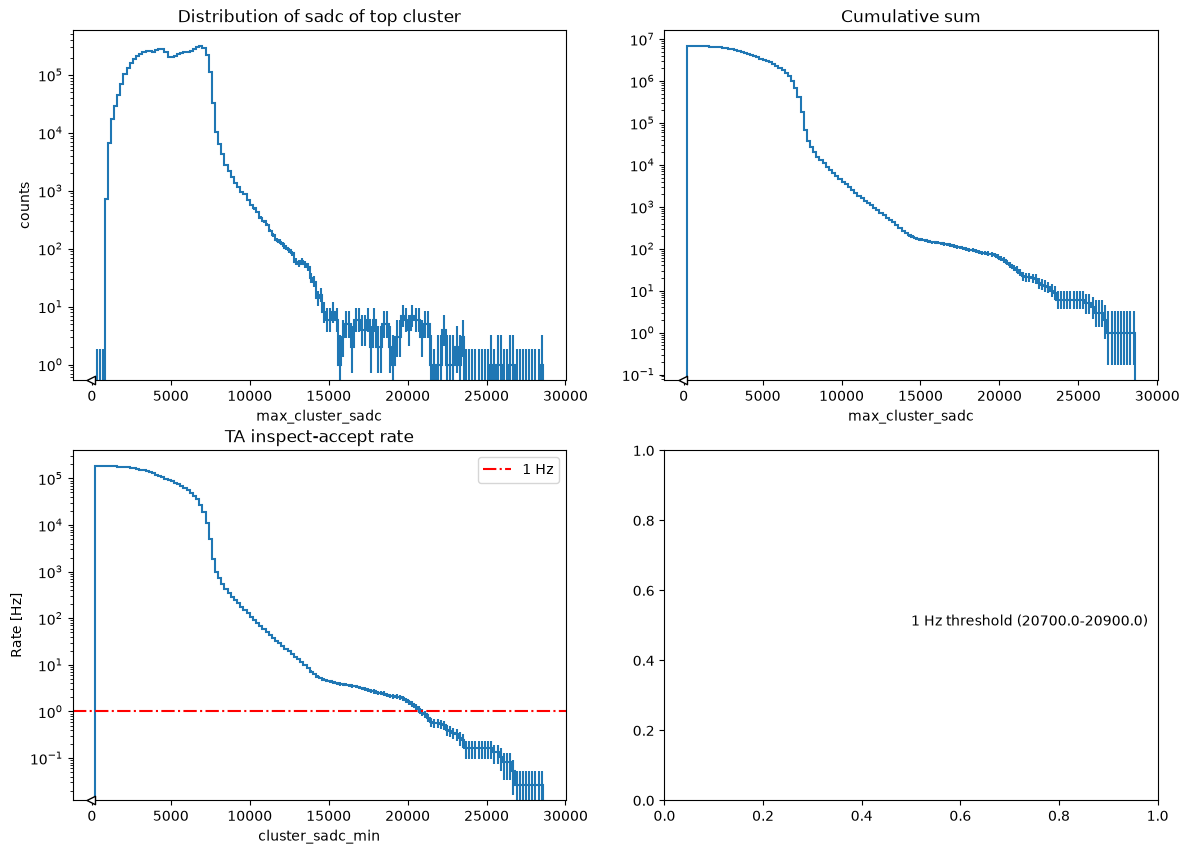

In [ ]:
from tpvalidator.analysis.histograms import make_regaxis, build_histogram, cumsum_hist_nd

clusters = taws.ta_win_cluster_stats
cl_sadc_axis = make_regaxis(clusters, 'max_cluster_sadc', 200)


h = build_histogram(clusters, [
    cl_sadc_axis
])


# Plot the sum adc of the top cluster in all inspect windows
fig, axes = plt.subplots(2, 2, figsize=(14,10))
ax = axes[0][0]
hep.histplot(h[1:], ax=ax)
ax.set_title('Distribution of sadc of top cluster')
ax.set_ylabel('counts')
ax.set_yscale('log')

# Plot the right-to-left cumulative sum
ax = axes[0][1]
ch = cumsum_hist_nd(h[1:], 0, 'right')
hep.histplot(ch, ax=ax)
ax.set_title('Cumulative sum')
ax.set_yscale('log')


ax = axes[1][0]

rh = (
    # Cumuative sum histogram
    ch / fdvd_time
)

hep.histplot(rh, ax=ax)
ax.set_title('TA inspect-accept rate')
ax.set_yscale('log')
ax.set_ylabel('Rate [Hz]')
ax.set_xlabel('cluster_sadc_min')

ax.axhline(1, label='1 Hz', c='red', ls='-.')
ax.legend()



target_rate = 1.

nb = len(rh.axes[0])

for i in range(nb-1, 0, -1):
    if rh[i].value > target_rate:
        print(rh[i], rh.axes[0].centers[i])
        print(rh[i+1], rh.axes[0].centers[i+1])

        thres_left = rh.axes[0].centers[i]
        thres_right = rh.axes[0].centers[i+1]
        break


ax = axes[1][1]

ax.text(0.5, 0.5, f'1 Hz threshold ({thres_left}-{thres_right})')

In [ ]:
taws.tree_names 


['event_summary',
 'mctruths',
 'ta_event_selection',
 'ta_win_stats',
 'ta_win_cluster_stats',
 'ta_clusters',
 'tps_with_cluster_flags']

<Axes: >

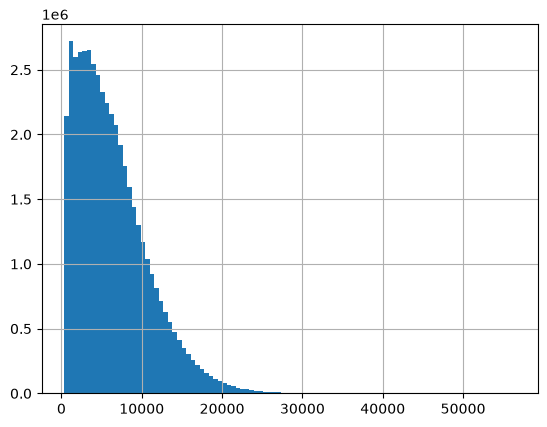

In [ ]:
taws.ta_win_stats.sadc.hist(bins=100)